<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/thermodynamics/RachRice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Flash calculations and the Rachford–Rice equation

This notebook opens the numerical core of a two-phase TP flash. We implement a safeguarded
Rachford–Rice solver, test it on a transparent synthetic example, and then benchmark it against
equilibrium ratios calculated by NeqSim for a multicomponent gas-condensate fluid.

## Learning objectives

You will learn to:

- classify liquid-only, vapour-only, and two-phase states from equilibrium ratios;
- solve the Rachford–Rice equation without allowing an unphysical phase fraction;
- reconstruct and validate liquid and vapour compositions;
- compare a transparent solver with a rigorous NeqSim TP flash;
- distinguish Wilson estimates from converged equation-of-state equilibrium ratios;
- interpret pressure sensitivity and separator product flows; and
- understand how PH and PS flashes wrap equilibrium calculations inside an energy specification.

## Preservation and extension note

All 15 original executable examples, all 17 original explanatory cells, and the original
four-panel technical figure are retained. The original material teaches the bounded
Rachford–Rice solution, composition reconstruction, a NeqSim TP-flash benchmark, Wilson
estimates, initial-guess robustness, pressure sensitivity, PH and PS flashes, separator
product accounting, and 19 acceptance checks.

The extension below adds four separate figures and a substantial final NeqSim application.
It uses `Stream`, `Separator`, and `ProcessSystem` to turn the thermodynamic flash into a
reusable process calculation. New graphics supplement rather than replace the previous
composite figure.

In [1]:
import importlib.metadata
import subprocess
import sys


try:
    neqsim_version = importlib.metadata.version("neqsim")
except importlib.metadata.PackageNotFoundError:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ],
        check=True,
    )
    neqsim_version = importlib.metadata.version("neqsim")

java_runtime = subprocess.run(
    ["java", "-version"],
    check=True,
    capture_output=True,
    text=True,
).stderr.splitlines()[0]

print(f"NeqSim package: {neqsim_version}")
print(f"Python runtime: {sys.version.split()[0]}")
print(f"Java runtime: {java_runtime}")

NeqSim package: 3.16.0
Python runtime: 3.12.13
Java runtime: openjdk version "17.0.19" 2026-04-21


## Engineering context

Flash calculations determine how a feed partitions between equilibrium phases. They appear in
separator models, distillation initialization, pipeline liquid-dropout studies, refrigeration,
depressurization, and process optimization. A reliable solver must return a physical answer
near phase boundaries and must identify when no two-phase root exists.

The Rachford–Rice equation closes the material balance when the equilibrium ratios $K_i$ are
known. In a rigorous equation-of-state flash, NeqSim updates the $K_i$ values until component
fugacities are equal; Rachford–Rice is therefore one important inner calculation, not the
complete thermodynamic model.

## Governing equations

For feed composition $z_i$, vapour fraction $\beta$, and equilibrium ratio $K_i=y_i/x_i$:

$$
R(\beta) =
\sum_i \frac{z_i(K_i-1)}
{1+\beta(K_i-1)}
$$

The physical two-phase solution satisfies $R(\beta)=0$ with $0<\beta<1$. Phase compositions
are:

$$
x_i = \frac{z_i}{1+\beta(K_i-1)}
$$

$$
y_i = K_i x_i
$$

The derivative is always non-positive away from degenerate cases:

$$
\frac{\mathrm{d}R}{\mathrm{d}\beta} =
-\sum_i
\frac{z_i(K_i-1)^2}
{\left[1+\beta(K_i-1)\right]^2}
$$

In [2]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from neqsim import jneqsim


plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.precision", 7)

COMPONENTS = {
    "methane": 0.720,
    "ethane": 0.080,
    "propane": 0.050,
    "n-butane": 0.040,
    "n-pentane": 0.035,
    "n-hexane": 0.030,
    "n-heptane": 0.025,
    "n-octane": 0.020,
}

BASE_TEMPERATURE_K = 260.0
BASE_PRESSURE_BARA = 40.0

## A bounded, safeguarded solver

Because $R(\beta)$ decreases monotonically, the endpoint signs classify the phase state:

- $R(0)\leq 0$: liquid-only under the supplied $K_i$ values;
- $R(1)\geq 0$: vapour-only; and
- $R(0)>0$ and $R(1)<0$: a two-phase root lies in $0<\beta<1$.

The implementation uses Newton steps when they remain inside the physical bracket and
bisection otherwise. This is more robust than unconstrained Newton iteration, which can step
outside the interval or approach a denominator singularity.

In [3]:
def rachford_rice_value(vapour_fraction, feed_fractions, equilibrium_ratios):
    denominator = 1.0 + vapour_fraction * (equilibrium_ratios - 1.0)
    numerator = feed_fractions * (equilibrium_ratios - 1.0)
    return float(np.sum(numerator / denominator))


def rachford_rice_derivative(
    vapour_fraction,
    feed_fractions,
    equilibrium_ratios,
):
    denominator = 1.0 + vapour_fraction * (equilibrium_ratios - 1.0)
    numerator = feed_fractions * np.square(equilibrium_ratios - 1.0)
    return float(-np.sum(numerator / np.square(denominator)))


def solve_rachford_rice(
    feed_fractions,
    equilibrium_ratios,
    initial_guess=0.5,
    tolerance=1e-12,
    maximum_iterations=100,
):
    feed_fractions = np.asarray(feed_fractions, dtype=float)
    equilibrium_ratios = np.asarray(equilibrium_ratios, dtype=float)

    if np.any(feed_fractions < 0.0):
        raise ValueError("Feed fractions must be non-negative.")
    if not math.isclose(float(feed_fractions.sum()), 1.0, abs_tol=1e-12):
        raise ValueError("Feed fractions must sum to one.")
    if np.any(equilibrium_ratios <= 0.0):
        raise ValueError("Equilibrium ratios must be positive.")

    liquid_endpoint = rachford_rice_value(
        0.0,
        feed_fractions,
        equilibrium_ratios,
    )
    vapour_endpoint = rachford_rice_value(
        1.0,
        feed_fractions,
        equilibrium_ratios,
    )

    if liquid_endpoint <= 0.0:
        return 0.0, "liquid only", []
    if vapour_endpoint >= 0.0:
        return 1.0, "vapour only", []

    lower_bound = 0.0
    upper_bound = 1.0
    vapour_fraction = float(np.clip(initial_guess, lower_bound, upper_bound))
    iteration_history = []

    for iteration in range(1, maximum_iterations + 1):
        residual = rachford_rice_value(
            vapour_fraction,
            feed_fractions,
            equilibrium_ratios,
        )
        derivative = rachford_rice_derivative(
            vapour_fraction,
            feed_fractions,
            equilibrium_ratios,
        )
        iteration_history.append(
            {
                "iteration": iteration,
                "vapour fraction [-]": vapour_fraction,
                "residual [-]": residual,
            }
        )

        if abs(residual) < tolerance:
            return vapour_fraction, "two phase", iteration_history

        if residual > 0.0:
            lower_bound = vapour_fraction
        else:
            upper_bound = vapour_fraction

        newton_candidate = vapour_fraction - residual / derivative
        if lower_bound < newton_candidate < upper_bound:
            vapour_fraction = newton_candidate
        else:
            vapour_fraction = 0.5 * (lower_bound + upper_bound)

    raise RuntimeError("Safeguarded Rachford–Rice solver did not converge.")

## Transparent synthetic example

The first example uses three components with prescribed $K_i$ values. These values are
deliberately synthetic so that the numerical calculation can be inspected independently of an
equation of state. The feed contains both a volatile and a strongly condensing component,
ensuring a physical two-phase root.

In [4]:
synthetic_components = ["light", "intermediate", "heavy"]
synthetic_feed = np.array([0.50, 0.30, 0.20])
synthetic_k_values = np.array([2.50, 0.80, 0.20])

synthetic_beta, synthetic_state, synthetic_history = solve_rachford_rice(
    feed_fractions=synthetic_feed,
    equilibrium_ratios=synthetic_k_values,
    initial_guess=0.5,
)

synthetic_history_table = pd.DataFrame(synthetic_history)

print(f"Classified state: {synthetic_state}")
print(f"Vapour fraction: {synthetic_beta:.10f}")
display(synthetic_history_table)

Classified state: two phase
Vapour fraction: 0.6232153777


,iteration,vapour fraction [-],residual [-]
0,1,0.5000000,9.5238095e-02
1,2,0.6290984,-4.8755054e-03
2,3,0.6232403,-2.0604979e-05
3,4,0.6232154,-3.6334086e-10
4,5,0.6232154,0.0000000e+00


## Reconstructing phase compositions

The phase compositions must each sum to one, and every component must satisfy:

$$
z_i = (1-\beta)x_i + \beta y_i
$$

These checks are essential. A small Rachford–Rice residual alone does not protect against a
coding error in the composition reconstruction.

In [5]:
def calculate_phase_compositions(
    feed_fractions,
    equilibrium_ratios,
    vapour_fraction,
):
    denominator = 1.0 + vapour_fraction * (equilibrium_ratios - 1.0)
    liquid_composition = feed_fractions / denominator
    vapour_composition = equilibrium_ratios * liquid_composition
    return liquid_composition, vapour_composition


synthetic_x, synthetic_y = calculate_phase_compositions(
    feed_fractions=synthetic_feed,
    equilibrium_ratios=synthetic_k_values,
    vapour_fraction=synthetic_beta,
)
synthetic_reconstructed_feed = (
    (1.0 - synthetic_beta) * synthetic_x
    + synthetic_beta * synthetic_y
)

synthetic_table = pd.DataFrame(
    {
        "component": synthetic_components,
        "z feed [-]": synthetic_feed,
        "K [-]": synthetic_k_values,
        "x liquid [-]": synthetic_x,
        "y vapour [-]": synthetic_y,
        "reconstructed z [-]": synthetic_reconstructed_feed,
    }
)

display(synthetic_table)
print(f"Liquid composition sum: {synthetic_x.sum():.12f}")
print(f"Vapour composition sum: {synthetic_y.sum():.12f}")

Liquid composition sum: 1.000000000000
Vapour composition sum: 1.000000000000


,component,z feed [-],K [-],x liquid [-],y vapour [-],reconstructed z [-]
0,light,0.5,2.5,0.2584216,0.6460539,0.5
1,intermediate,0.3,0.8,0.3427173,0.2741739,0.3
2,heavy,0.2,0.2,0.3988611,0.0797722,0.2


## NeqSim base fluid and TP flash

The rigorous benchmark uses SRK with the classic mixing rule and a synthetic hydrocarbon feed.
Multiphase checking is enabled before the flash. NeqSim iterates the equation-of-state
fugacity coefficients and phase split to equilibrium, then initializes physical properties.

In [6]:
def build_hydrocarbon_fluid(temperature_k, pressure_bara):
    fluid = jneqsim.thermo.system.SystemSrkEos(
        temperature_k,
        pressure_bara,
    )

    for component_name, mole_fraction in COMPONENTS.items():
        fluid.addComponent(component_name, mole_fraction)

    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)
    return fluid


def run_tp_flash(fluid):
    operations = jneqsim.thermodynamicoperations.ThermodynamicOperations(fluid)
    operations.TPflash()
    fluid.initProperties()
    return fluid


base_fluid = build_hydrocarbon_fluid(
    temperature_k=BASE_TEMPERATURE_K,
    pressure_bara=BASE_PRESSURE_BARA,
)
run_tp_flash(base_fluid)

gas_phase = base_fluid.getPhase("gas")
oil_phase = base_fluid.getPhase("oil")
neqsim_beta = float(gas_phase.getBeta())

print(f"NeqSim phase count: {base_fluid.getNumberOfPhases()}")
print(f"NeqSim vapour fraction: {neqsim_beta:.10f}")
print(f"Gas density: {gas_phase.getDensity('kg/m3'):.3f} kg/m³")
print(f"Oil density: {oil_phase.getDensity('kg/m3'):.3f} kg/m³")

NeqSim phase count: 2
NeqSim vapour fraction: 0.7240295678
Gas density: 38.921 kg/m³
Oil density: 602.501 kg/m³


## Extracting converged equilibrium ratios

For a converged NeqSim flash, $K_i=y_i/x_i$. Light methane should have $K_i>1$, while the
normal paraffins become progressively less volatile with carbon number. The extracted values
are inputs to our independent Rachford–Rice calculation.

In [7]:
neqsim_rows = []

for component_name, feed_fraction in COMPONENTS.items():
    gas_component = gas_phase.getComponent(component_name)
    oil_component = oil_phase.getComponent(component_name)
    vapour_composition = float(gas_component.getx())
    liquid_composition = float(oil_component.getx())

    neqsim_rows.append(
        {
            "component": component_name,
            "z feed [-]": feed_fraction,
            "x liquid [-]": liquid_composition,
            "y vapour [-]": vapour_composition,
            "K NeqSim [-]": vapour_composition / liquid_composition,
        }
    )

neqsim_equilibrium = pd.DataFrame(neqsim_rows)
display(neqsim_equilibrium)

,component,z feed [-],x liquid [-],y vapour [-],K NeqSim [-]
0,methane,0.720,0.2332530,0.9055280,3.8821703
1,ethane,0.080,0.1143332,0.0669136,0.5852505
2,propane,0.050,0.1285057,0.0200769,0.1562333
3,n-butane,0.040,0.1304997,0.0055052,0.0421855
4,n-pentane,0.035,0.1229330,0.0014836,0.0120680
5,n-hexane,0.030,0.1077230,0.0003752,0.0034828
6,n-heptane,0.025,0.0903407,0.0000948,0.0010494
7,n-octane,0.020,0.0724117,0.0000228,0.0003150


## Independent benchmark against NeqSim

Using NeqSim's converged $K_i$ values isolates the material-balance calculation. The
transparent solver should reproduce NeqSim's vapour fraction and phase compositions to near
floating-point precision.

In [8]:
feed_vector = neqsim_equilibrium["z feed [-]"].to_numpy()
neqsim_k_vector = neqsim_equilibrium["K NeqSim [-]"].to_numpy()

independent_beta, independent_state, independent_history = solve_rachford_rice(
    feed_fractions=feed_vector,
    equilibrium_ratios=neqsim_k_vector,
    initial_guess=0.5,
)
independent_x, independent_y = calculate_phase_compositions(
    feed_fractions=feed_vector,
    equilibrium_ratios=neqsim_k_vector,
    vapour_fraction=independent_beta,
)

beta_difference = independent_beta - neqsim_beta
maximum_liquid_composition_difference = float(
    np.max(
        np.abs(
            independent_x
            - neqsim_equilibrium["x liquid [-]"].to_numpy()
        )
    )
)
maximum_vapour_composition_difference = float(
    np.max(
        np.abs(
            independent_y
            - neqsim_equilibrium["y vapour [-]"].to_numpy()
        )
    )
)

print(f"Independent state: {independent_state}")
print(f"Independent vapour fraction: {independent_beta:.10f}")
print(f"Vapour-fraction difference: {beta_difference:.3e}")
print(
    "Maximum liquid-composition difference: "
    f"{maximum_liquid_composition_difference:.3e}"
)
print(
    "Maximum vapour-composition difference: "
    f"{maximum_vapour_composition_difference:.3e}"
)

Independent state: two phase
Independent vapour fraction: 0.7240295678
Vapour-fraction difference: -2.220e-16
Maximum liquid-composition difference: 5.551e-17
Maximum vapour-composition difference: 2.220e-16


## Wilson estimates versus converged values

Wilson's correlation provides a useful initialization:

$$
\ln K_i =
\ln\left(\frac{P_{c,i}}{P}\right)
+ 5.373(1+\omega_i)
\left(1-\frac{T_{c,i}}{T}\right)
$$

Here $T_{c,i}$, $P_{c,i}$, and $\omega_i$ are critical temperature, critical pressure, and
acentric factor. Wilson values are estimates for initialization and screening; they do not
enforce fugacity equality for the mixture.

In [9]:
wilson_k_values = []

for component_name in COMPONENTS:
    component = base_fluid.getPhase(0).getComponent(component_name)
    critical_temperature_k = float(component.getTC())
    critical_pressure_bara = float(component.getPC())
    acentric_factor = float(component.getAcentricFactor())

    logarithm_k = math.log(critical_pressure_bara / BASE_PRESSURE_BARA)
    logarithm_k += (
        5.373
        * (1.0 + acentric_factor)
        * (1.0 - critical_temperature_k / BASE_TEMPERATURE_K)
    )
    wilson_k_values.append(math.exp(logarithm_k))

wilson_k_vector = np.array(wilson_k_values)
wilson_beta, wilson_state, _ = solve_rachford_rice(
    feed_fractions=feed_vector,
    equilibrium_ratios=wilson_k_vector,
)

k_comparison = neqsim_equilibrium[["component", "K NeqSim [-]"]].copy()
k_comparison["K Wilson [-]"] = wilson_k_vector
k_comparison["Wilson / NeqSim [-]"] = (
    k_comparison["K Wilson [-]"] / k_comparison["K NeqSim [-]"]
)

display(k_comparison)
print(f"Wilson-classified state: {wilson_state}")
print(f"Wilson vapour fraction: {wilson_beta:.6f}")

Wilson-classified state: two phase
Wilson vapour fraction: 0.719509


,component,K NeqSim [-],K Wilson [-],Wilson / NeqSim [-]
0,methane,3.8821703,4.9089074,1.2644750
1,ethane,0.5852505,0.4349465,0.7431801
2,propane,0.1562333,0.0776769,0.4971854
3,n-butane,0.0421855,0.0157999,0.3745339
4,n-pentane,0.0120680,0.0037172,0.3080177
5,n-hexane,0.0034828,0.0009704,0.2786246
6,n-heptane,0.0010494,0.0002767,0.2636838
7,n-octane,0.0003150,0.0000825,0.2619256


## Initial-guess robustness

The same physical root is solved from guesses close to either endpoint. The iteration count
may change, but the safeguarded method retains the bracket and converges to the same result.

In [10]:
initial_guesses = [0.01, 0.25, 0.50, 0.75, 0.99]
initial_guess_rows = []

for initial_guess in initial_guesses:
    solved_beta, solved_state, history = solve_rachford_rice(
        feed_fractions=feed_vector,
        equilibrium_ratios=neqsim_k_vector,
        initial_guess=initial_guess,
    )
    initial_guess_rows.append(
        {
            "initial guess [-]": initial_guess,
            "state": solved_state,
            "iterations": len(history),
            "vapour fraction [-]": solved_beta,
            "difference from NeqSim [-]": solved_beta - neqsim_beta,
        }
    )

initial_guess_study = pd.DataFrame(initial_guess_rows)
display(initial_guess_study)

,initial guess [-],state,iterations,vapour fraction [-],difference from NeqSim [-]
0,0.01,two phase,7,0.7240296,-2.2204460e-16
1,0.25,two phase,6,0.7240296,1.3244961e-13
2,0.50,two phase,6,0.7240296,-2.2204460e-16
3,0.75,two phase,5,0.7240296,-2.2204460e-16
4,0.99,two phase,10,0.7240296,-2.2204460e-16


## Pressure study and phase-state classification

At fixed temperature, higher pressure condenses more of this gas-condensate feed. For every
case, a fresh NeqSim fluid provides converged $K_i$ values; the independent solver then
reproduces the phase fraction. This checks both trend and algorithm across a useful range.

In [11]:
pressure_values_bara = np.arange(5.0, 105.0, 5.0)
pressure_rows = []

for pressure_bara in pressure_values_bara:
    scenario_fluid = build_hydrocarbon_fluid(
        temperature_k=BASE_TEMPERATURE_K,
        pressure_bara=float(pressure_bara),
    )
    run_tp_flash(scenario_fluid)

    scenario_gas = scenario_fluid.getPhase("gas")
    scenario_oil = scenario_fluid.getPhase("oil")
    scenario_k_values = []

    for component_name in COMPONENTS:
        scenario_y = float(scenario_gas.getComponent(component_name).getx())
        scenario_x = float(scenario_oil.getComponent(component_name).getx())
        scenario_k_values.append(scenario_y / scenario_x)

    scenario_beta = float(scenario_gas.getBeta())
    solved_beta, solved_state, _ = solve_rachford_rice(
        feed_fractions=feed_vector,
        equilibrium_ratios=np.array(scenario_k_values),
    )
    pressure_rows.append(
        {
            "pressure [bara]": pressure_bara,
            "state": solved_state,
            "NeqSim vapour fraction [-]": scenario_beta,
            "independent vapour fraction [-]": solved_beta,
            "difference [-]": solved_beta - scenario_beta,
        }
    )

pressure_study = pd.DataFrame(pressure_rows)
display(pressure_study.iloc[::4].reset_index(drop=True))

,pressure [bara],state,NeqSim vapour fraction [-],independent vapour fraction [-],difference [-]
0,5.0,two phase,0.8559528,0.8559528,1.1616708e-11
1,25.0,two phase,0.7702909,0.7702909,4.4408921e-16
2,45.0,two phase,0.7087599,0.7087599,0.0000000e+00
3,65.0,two phase,0.6444092,0.6444092,-2.2204460e-16
4,85.0,two phase,0.5699558,0.5699558,-2.2204460e-16


## PH and PS flashes

A PH flash finds temperature and phase split at specified pressure and enthalpy; a PS flash
does the same at specified pressure and entropy. They contain an outer energy or entropy
specification around equilibrium calculations. An ideal throttle is approximately
isenthalpic, while a reversible adiabatic expander is approximately isentropic.

The residuals below use total enthalpy in joules and total entropy in joules per kelvin for the
one-mole calculation basis.

In [12]:
expansion_feed = jneqsim.thermo.system.SystemSrkEos(300.0, 80.0)

for component_name, mole_fraction in {
    "nitrogen": 0.01,
    "CO2": 0.02,
    "methane": 0.82,
    "ethane": 0.08,
    "propane": 0.04,
    "n-butane": 0.02,
    "n-pentane": 0.01,
}.items():
    expansion_feed.addComponent(component_name, mole_fraction)

expansion_feed.setMixingRule("classic")
expansion_feed.setMultiPhaseCheck(True)
run_tp_flash(expansion_feed)

feed_enthalpy_j = float(expansion_feed.getEnthalpy("J"))
feed_entropy_j_per_k = float(expansion_feed.getEntropy("J/K"))

throttle_fluid = expansion_feed.clone()
throttle_fluid.setPressure(20.0, "bara")
throttle_operations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations(throttle_fluid)
)
throttle_operations.PHflash(feed_enthalpy_j)
throttle_fluid.initProperties()

isentropic_fluid = expansion_feed.clone()
isentropic_fluid.setPressure(20.0, "bara")
isentropic_operations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations(isentropic_fluid)
)
isentropic_operations.PSflash(feed_entropy_j_per_k)
isentropic_fluid.initProperties()

enthalpy_residual_j = float(
    throttle_fluid.getEnthalpy("J") - feed_enthalpy_j
)
entropy_residual_j_per_k = float(
    isentropic_fluid.getEntropy("J/K") - feed_entropy_j_per_k
)

flash_specification_table = pd.DataFrame(
    [
        {
            "flash": "PH throttle",
            "outlet temperature [K]": float(throttle_fluid.getTemperature("K")),
            "phase count": int(throttle_fluid.getNumberOfPhases()),
            "specified-property residual": enthalpy_residual_j,
            "residual unit": "J",
        },
        {
            "flash": "PS expansion",
            "outlet temperature [K]": float(isentropic_fluid.getTemperature("K")),
            "phase count": int(isentropic_fluid.getNumberOfPhases()),
            "specified-property residual": entropy_residual_j_per_k,
            "residual unit": "J/K",
        },
    ]
)

display(flash_specification_table)

,flash,outlet temperature [K],phase count,specified-property residual,residual unit
0,PH throttle,266.7967098,2,-0.0000026,J
1,PS expansion,231.6336669,2,0.0000029,J/K


## Separator product accounting

For feed flow $F$, vapour flow is $V=\beta F$ and liquid flow is
$L=(1-\beta)F$. Component flows $Vy_i$ and $Lx_i$ must reconstruct $Fz_i$.
This translates the numerical root into an engineering material balance.

In [13]:
feed_flow_kmol_per_h = 1000.0
gas_flow_kmol_per_h = neqsim_beta * feed_flow_kmol_per_h
liquid_flow_kmol_per_h = (1.0 - neqsim_beta) * feed_flow_kmol_per_h

product_table = neqsim_equilibrium[
    ["component", "z feed [-]", "x liquid [-]", "y vapour [-]"]
].copy()
product_table["feed [kmol/h]"] = (
    feed_flow_kmol_per_h * product_table["z feed [-]"]
)
product_table["gas [kmol/h]"] = (
    gas_flow_kmol_per_h * product_table["y vapour [-]"]
)
product_table["liquid [kmol/h]"] = (
    liquid_flow_kmol_per_h * product_table["x liquid [-]"]
)
product_table["component residual [kmol/h]"] = (
    product_table["gas [kmol/h]"]
    + product_table["liquid [kmol/h]"]
    - product_table["feed [kmol/h]"]
)

maximum_flow_residual = float(
    product_table["component residual [kmol/h]"].abs().max()
)

display(product_table)
print(f"Gas product: {gas_flow_kmol_per_h:.3f} kmol/h")
print(f"Liquid product: {liquid_flow_kmol_per_h:.3f} kmol/h")

Gas product: 724.030 kmol/h
Liquid product: 275.970 kmol/h


,component,z feed [-],x liquid [-],y vapour [-],feed [kmol/h],gas [kmol/h],liquid [kmol/h],component residual [kmol/h]
0,methane,0.720,0.2332530,0.9055280,720.0,655.6290584,64.3709416,2.2737368e-13
1,ethane,0.080,0.1143332,0.0669136,80.0,48.4474086,31.5525914,2.8421709e-14
2,propane,0.050,0.1285057,0.0200769,50.0,14.5362392,35.4637608,-7.1054274e-15
3,n-butane,0.040,0.1304997,0.0055052,40.0,3.9859282,36.0140718,-7.1054274e-15
4,n-pentane,0.035,0.1229330,0.0014836,35.0,1.0741379,33.9258621,-1.4210855e-14
5,n-hexane,0.030,0.1077230,0.0003752,30.0,0.2716396,29.7283604,-1.0658141e-14
6,n-heptane,0.025,0.0903407,0.0000948,25.0,0.0686409,24.9313591,-7.1054274e-15
7,n-octane,0.020,0.0724117,0.0000228,20.0,0.0165150,19.9834850,-7.1054274e-15


## Numerical behaviour and engineering trends

The figure shows the monotonic Rachford–Rice residual, convergence of the safeguarded
iterations, the difference between estimated and converged $K_i$ values, and pressure-driven
condensation. All curves are calculated deterministically from the notebook inputs.

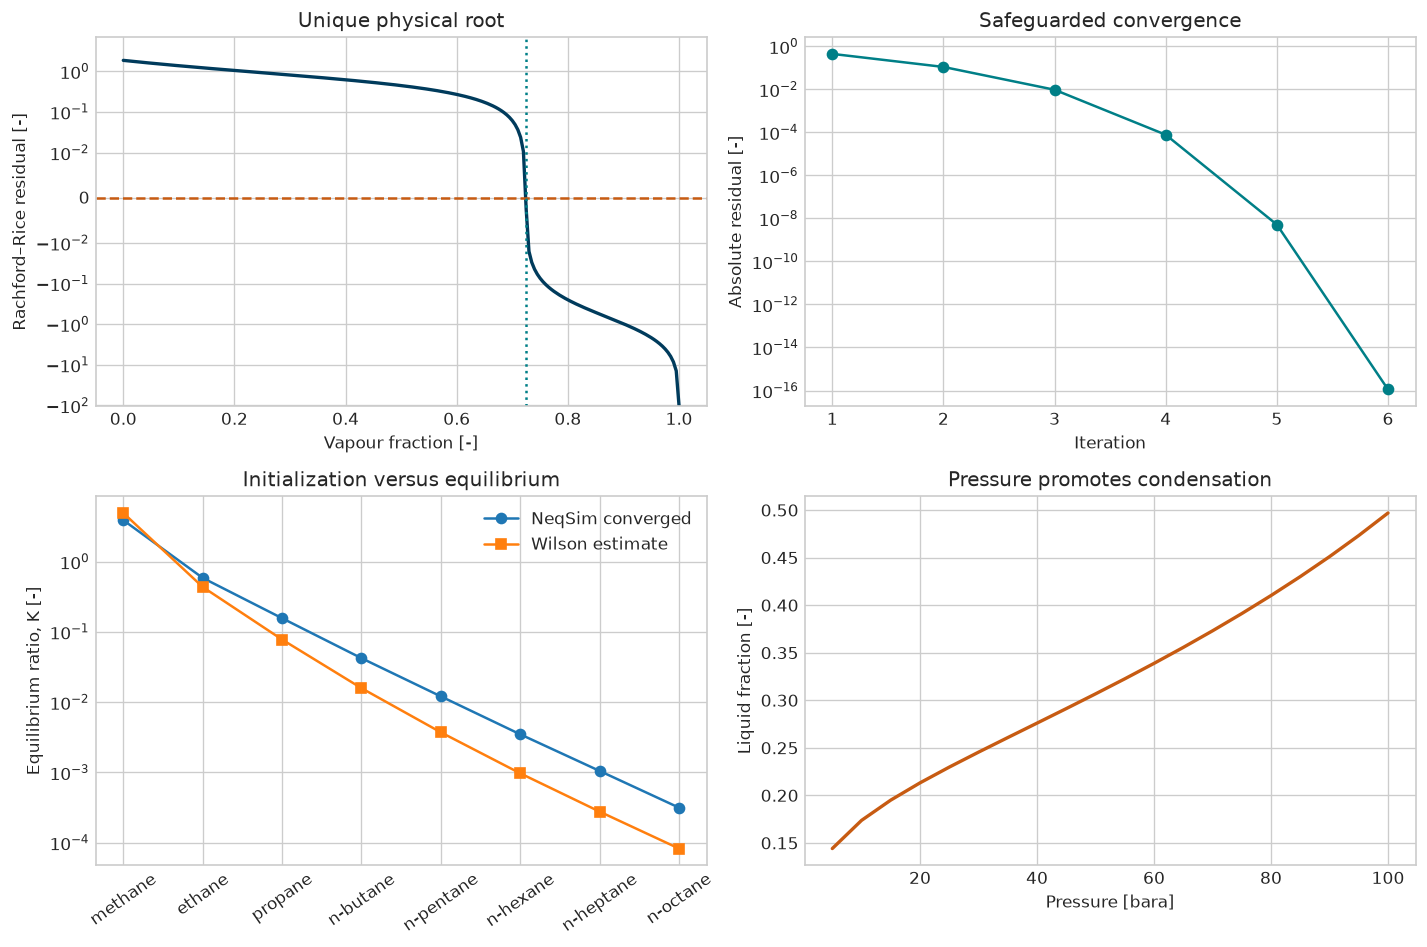

In [14]:
beta_grid = np.linspace(0.0, 1.0, 201)
residual_grid = [
    rachford_rice_value(beta, feed_vector, neqsim_k_vector)
    for beta in beta_grid
]
benchmark_history = pd.DataFrame(independent_history)

figure, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(beta_grid, residual_grid, color="#003B5C", linewidth=2)
axes[0, 0].axhline(0.0, color="#C75B12", linestyle="--")
axes[0, 0].axvline(neqsim_beta, color="#007F87", linestyle=":")
axes[0, 0].set_yscale("symlog", linthresh=0.01)
axes[0, 0].set_xlabel("Vapour fraction [-]")
axes[0, 0].set_ylabel("Rachford–Rice residual [-]")
axes[0, 0].set_title("Unique physical root")

axes[0, 1].semilogy(
    benchmark_history["iteration"],
    benchmark_history["residual [-]"].abs() + 1e-18,
    marker="o",
    color="#007F87",
)
axes[0, 1].set_xlabel("Iteration")
axes[0, 1].set_ylabel("Absolute residual [-]")
axes[0, 1].set_title("Safeguarded convergence")

axes[1, 0].semilogy(
    k_comparison["component"],
    k_comparison["K NeqSim [-]"],
    marker="o",
    label="NeqSim converged",
)
axes[1, 0].semilogy(
    k_comparison["component"],
    k_comparison["K Wilson [-]"],
    marker="s",
    label="Wilson estimate",
)
axes[1, 0].set_ylabel("Equilibrium ratio, K [-]")
axes[1, 0].set_title("Initialization versus equilibrium")
axes[1, 0].tick_params(axis="x", rotation=35)
axes[1, 0].legend()

axes[1, 1].plot(
    pressure_study["pressure [bara]"],
    1.0 - pressure_study["NeqSim vapour fraction [-]"],
    color="#C75B12",
    linewidth=2,
)
axes[1, 1].set_xlabel("Pressure [bara]")
axes[1, 1].set_ylabel("Liquid fraction [-]")
axes[1, 1].set_title("Pressure promotes condensation")

figure.tight_layout()
plt.show()

## Final application: a reusable NeqSim separator workflow

The transparent Rachford–Rice calculation explains the inner material balance. A process
model also needs named streams, equipment, execution order, result retrieval, and
conservation checks. NeqSim represents these with:

- a thermodynamic system containing components, state, and the SRK model;
- a `Stream` that assigns an engineering flow rate to that fluid;
- a `Separator` that performs the equilibrium phase split; and
- a `ProcessSystem` that runs connected equipment in a defined order.

For the separator boundary, total mass and each component must close:

$$
\dot{m}_{feed} = \dot{m}_{gas} + \dot{m}_{liquid}
$$

$$
\dot{n}_{i,feed} =
\dot{n}_{i,gas} + \dot{n}_{i,liquid}
$$

The case function below creates fresh objects every time. This prevents a pressure sweep
from inheriting hidden state from the preceding case.

In [15]:
Stream = jneqsim.process.equipment.stream.Stream
Separator = jneqsim.process.equipment.separator.Separator
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


def simulate_separator_case(
    pressure_bara,
    temperature_k=BASE_TEMPERATURE_K,
    feed_flow_kg_per_h=10000.0,
):
    fluid = build_hydrocarbon_fluid(
        temperature_k=temperature_k,
        pressure_bara=pressure_bara,
    )
    case_name = f"separator case at {pressure_bara:.0f} bara"
    feed_stream = Stream(f"{case_name} feed", fluid)
    feed_stream.setFlowRate(feed_flow_kg_per_h, "kg/hr")
    separator = Separator(case_name, feed_stream)

    process = ProcessSystem()
    process.add(feed_stream)
    process.add(separator)
    process.run()

    gas_stream = separator.getGasOutStream()
    liquid_stream = separator.getLiquidOutStream()
    feed_mass_flow = float(feed_stream.getFlowRate("kg/hr"))
    gas_mass_flow = float(gas_stream.getFlowRate("kg/hr"))
    liquid_mass_flow = float(liquid_stream.getFlowRate("kg/hr"))
    feed_molar_flow = float(feed_stream.getFlowRate("mole/sec"))
    gas_molar_flow = float(gas_stream.getFlowRate("mole/sec"))
    liquid_molar_flow = float(liquid_stream.getFlowRate("mole/sec"))
    component_rows = []

    for component_name in COMPONENTS:
        feed_fraction = float(
            feed_stream.getFluid().getComponent(component_name).getz()
        )
        gas_fraction = float(
            gas_stream.getFluid().getComponent(component_name).getz()
        )
        liquid_fraction = float(
            liquid_stream.getFluid().getComponent(component_name).getz()
        )
        feed_component_flow = feed_molar_flow * feed_fraction
        gas_component_flow = gas_molar_flow * gas_fraction
        liquid_component_flow = liquid_molar_flow * liquid_fraction
        component_rows.append(
            {
                "component": component_name,
                "feed [mol/s]": feed_component_flow,
                "gas recovery [-]": (
                    gas_component_flow / feed_component_flow
                ),
                "liquid recovery [-]": (
                    liquid_component_flow / feed_component_flow
                ),
                "component residual [mol/s]": (
                    feed_component_flow
                    - gas_component_flow
                    - liquid_component_flow
                ),
            }
        )

    component_table = pd.DataFrame(component_rows)
    return {
        "process": process,
        "feed_stream": feed_stream,
        "separator": separator,
        "gas_stream": gas_stream,
        "liquid_stream": liquid_stream,
        "pressure_bara": pressure_bara,
        "temperature_k": temperature_k,
        "feed_mass_flow_kg_per_h": feed_mass_flow,
        "gas_mass_flow_kg_per_h": gas_mass_flow,
        "liquid_mass_flow_kg_per_h": liquid_mass_flow,
        "liquid_mass_fraction": (
            liquid_mass_flow / feed_mass_flow
        ),
        "mass_residual_kg_per_h": (
            feed_mass_flow
            - gas_mass_flow
            - liquid_mass_flow
        ),
        "component_table": component_table,
        "maximum_component_residual_mol_per_s": float(
            component_table[
                "component residual [mol/s]"
            ].abs().max()
        ),
    }

### Base process case and retrieved engineering results

The base case assigns 10,000 kg/h to the same 260 K, 40 bara fluid used in the
thermodynamic benchmark. The process equipment performs its own flash. Retrieved stream
rates are compared with the feed, and the liquid mass fraction is reported with explicit
units.

In [16]:
base_separator_case = simulate_separator_case(
    pressure_bara=BASE_PRESSURE_BARA,
)

base_process_table = pd.DataFrame(
    [
        {
            "quantity": "feed mass flow",
            "value": base_separator_case[
                "feed_mass_flow_kg_per_h"
            ],
            "unit": "kg/h",
        },
        {
            "quantity": "gas product",
            "value": base_separator_case[
                "gas_mass_flow_kg_per_h"
            ],
            "unit": "kg/h",
        },
        {
            "quantity": "liquid product",
            "value": base_separator_case[
                "liquid_mass_flow_kg_per_h"
            ],
            "unit": "kg/h",
        },
        {
            "quantity": "liquid mass fraction",
            "value": base_separator_case[
                "liquid_mass_fraction"
            ],
            "unit": "-",
        },
        {
            "quantity": "mass residual",
            "value": base_separator_case[
                "mass_residual_kg_per_h"
            ],
            "unit": "kg/h",
        },
    ]
)

display(base_process_table)
print(
    "Base separator completed: "
    f"{base_separator_case['gas_mass_flow_kg_per_h']:.6f} kg/h gas, "
    f"{base_separator_case['liquid_mass_flow_kg_per_h']:.6f} kg/h liquid."
)

Base separator completed: 4564.617440 kg/h gas, 5435.382560 kg/h liquid.


,quantity,value,unit
0,feed mass flow,1.0000000e+04,kg/h
1,gas product,4.5646174e+03,kg/h
2,liquid product,5.4353826e+03,kg/h
3,liquid mass fraction,5.4353826e-01,-
4,mass residual,-1.8189894e-12,kg/h


### Figure 2 — process objects and solver workflow

The process diagram shows what the final application adds to the thermodynamic flash:
engineering flow, named equipment, ordered execution, product retrieval, and independent
balance checks. The process remains deliberately small so each API object has a clear
purpose.

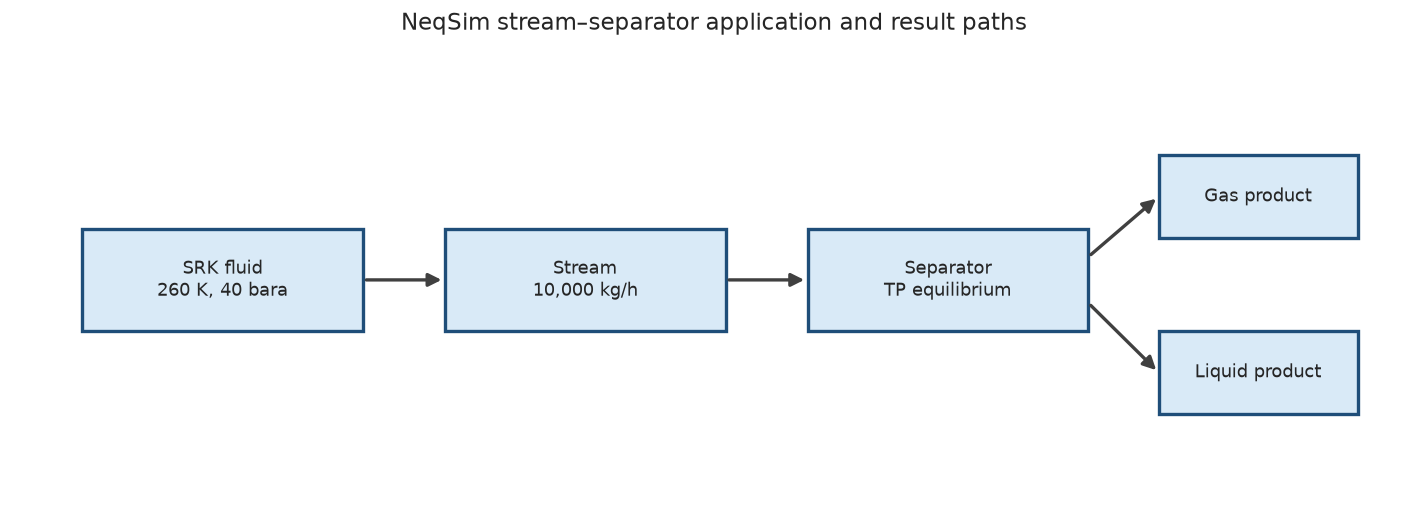

In [17]:
figure, axis = plt.subplots(figsize=(12, 4.5))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 5.0)
axis.axis("off")

workflow_boxes = [
    (0.6, 2.0, 2.4, 1.1, "SRK fluid\n260 K, 40 bara"),
    (3.7, 2.0, 2.4, 1.1, "Stream\n10,000 kg/h"),
    (6.8, 2.0, 2.4, 1.1, "Separator\nTP equilibrium"),
    (9.8, 3.0, 1.7, 0.9, "Gas product"),
    (9.8, 1.1, 1.7, 0.9, "Liquid product"),
]

for left, bottom, width, height, label in workflow_boxes:
    rectangle = plt.Rectangle(
        (left, bottom),
        width,
        height,
        facecolor="#D9EAF7",
        edgecolor="#1F4E79",
        linewidth=2,
    )
    axis.add_patch(rectangle)
    axis.text(
        left + width / 2.0,
        bottom + height / 2.0,
        label,
        ha="center",
        va="center",
        fontsize=11,
    )

arrow_style = {
    "arrowstyle": "-|>",
    "color": "#404040",
    "linewidth": 2,
    "mutation_scale": 16,
}
axis.annotate("", xy=(3.7, 2.55), xytext=(3.0, 2.55), arrowprops=arrow_style)
axis.annotate("", xy=(6.8, 2.55), xytext=(6.1, 2.55), arrowprops=arrow_style)
axis.annotate("", xy=(9.8, 3.45), xytext=(9.2, 2.8), arrowprops=arrow_style)
axis.annotate("", xy=(9.8, 1.55), xytext=(9.2, 2.3), arrowprops=arrow_style)
axis.set_title(
    "NeqSim stream–separator application and result paths",
    fontsize=14,
    pad=14,
)
figure.tight_layout()
plt.show()

The two product paths are read directly from the NeqSim `Separator`. The same object model
can be extended with heaters, valves, compressors, mixers, recycle loops, or controllers
without changing the underlying balance principles.

### Figure 3 — component recovery by product

Recovery makes the phase split operationally meaningful. Methane should remain mostly in
the gas, while heavier normal paraffins increasingly report to the liquid. Gas and liquid
recoveries must sum to one for every component.

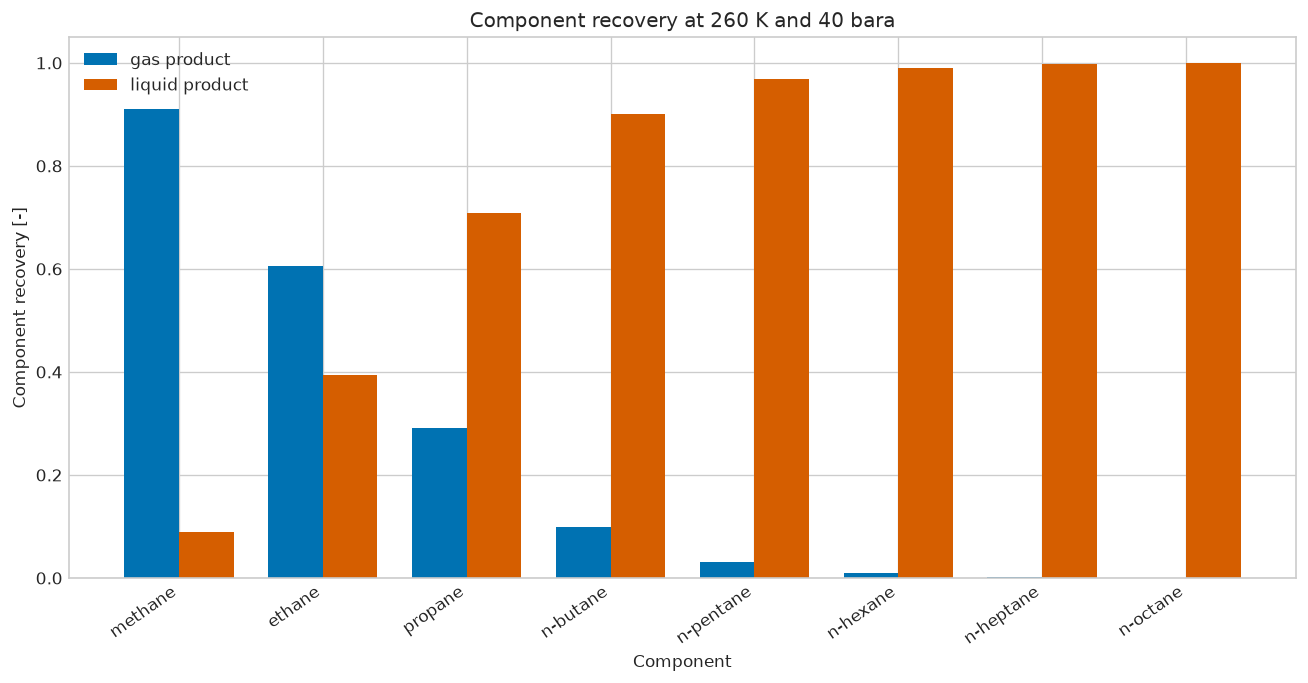

In [18]:
base_component_table = base_separator_case["component_table"].copy()
component_positions = np.arange(len(base_component_table))
bar_width = 0.38

figure, axis = plt.subplots(figsize=(11, 5.8))
axis.bar(
    component_positions - bar_width / 2.0,
    base_component_table["gas recovery [-]"],
    width=bar_width,
    label="gas product",
    color="#0072B2",
)
axis.bar(
    component_positions + bar_width / 2.0,
    base_component_table["liquid recovery [-]"],
    width=bar_width,
    label="liquid product",
    color="#D55E00",
)
axis.set_xticks(
    component_positions,
    base_component_table["component"],
    rotation=35,
    ha="right",
)
axis.set_ylabel("Component recovery [-]")
axis.set_xlabel("Component")
axis.set_ylim(0.0, 1.05)
axis.set_title(
    "Component recovery at 260 K and 40 bara"
)
axis.legend()
figure.tight_layout()
plt.show()

Methane is concentrated in the gas product, whereas the heavy components are concentrated
in the liquid. Intermediate components split between both products. This is the same
equilibrium behaviour quantified by the $K_i$ values earlier in the notebook.

### Pressure scenario analysis

Five fresh process models are evaluated from 20 to 60 bara at 260 K. Pressure is the only
changed input. The expected trend is increasing condensation with pressure, while every
case must independently close total and component balances.

In [19]:
separator_pressures_bara = [20.0, 30.0, 40.0, 50.0, 60.0]
separator_cases = [
    simulate_separator_case(pressure_bara=pressure_bara)
    for pressure_bara in separator_pressures_bara
]
separator_sensitivity = pd.DataFrame(
    [
        {
            "pressure [bara]": case["pressure_bara"],
            "gas flow [kg/h]": case["gas_mass_flow_kg_per_h"],
            "liquid flow [kg/h]": case[
                "liquid_mass_flow_kg_per_h"
            ],
            "liquid mass fraction [-]": case[
                "liquid_mass_fraction"
            ],
            "mass residual [kg/h]": case[
                "mass_residual_kg_per_h"
            ],
            "maximum component residual [mol/s]": case[
                "maximum_component_residual_mol_per_s"
            ],
        }
        for case in separator_cases
    ]
)

display(separator_sensitivity)

,pressure [bara],gas flow [kg/h],liquid flow [kg/h],liquid mass fraction [-],mass residual [kg/h],maximum component residual [mol/s]
0,20.0,5101.3580268,4898.6419732,0.4898642,-4.4565240e-11,1.9051427e-13
1,30.0,4805.1177718,5194.8822282,0.5194882,9.0949470e-13,8.8817842e-16
2,40.0,4564.6174404,5435.3825596,0.5435383,-1.8189894e-12,6.2172489e-15
3,50.0,4347.0278588,5652.9721413,0.5652972,-7.5080607e-08,3.7633896e-10
4,60.0,4137.1570125,5862.8429875,0.5862843,-1.8189894e-12,1.0658141e-14


### Figure 4 — principal process result

The product-flow curves show how pressure changes the separator split at fixed temperature
and feed rate. The secondary axis reports liquid mass fraction, which is often more useful
for capacity and downstream equipment studies than molar vapour fraction alone.

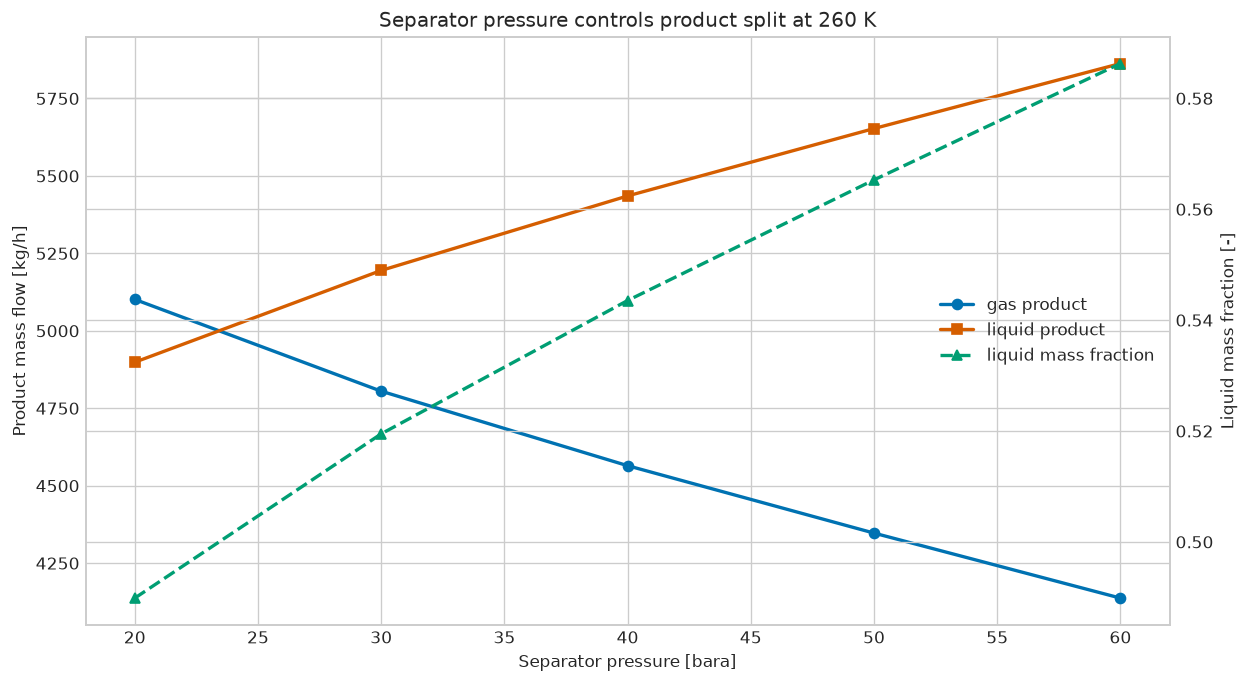

In [20]:
figure, flow_axis = plt.subplots(figsize=(10.5, 5.8))
fraction_axis = flow_axis.twinx()

flow_axis.plot(
    separator_sensitivity["pressure [bara]"],
    separator_sensitivity["gas flow [kg/h]"],
    marker="o",
    linewidth=2,
    label="gas product",
    color="#0072B2",
)
flow_axis.plot(
    separator_sensitivity["pressure [bara]"],
    separator_sensitivity["liquid flow [kg/h]"],
    marker="s",
    linewidth=2,
    label="liquid product",
    color="#D55E00",
)
fraction_axis.plot(
    separator_sensitivity["pressure [bara]"],
    separator_sensitivity["liquid mass fraction [-]"],
    marker="^",
    linestyle="--",
    linewidth=2,
    label="liquid mass fraction",
    color="#009E73",
)
flow_axis.set_xlabel("Separator pressure [bara]")
flow_axis.set_ylabel("Product mass flow [kg/h]")
fraction_axis.set_ylabel("Liquid mass fraction [-]")
flow_axis.set_title(
    "Separator pressure controls product split at 260 K"
)
flow_lines, flow_labels = flow_axis.get_legend_handles_labels()
fraction_lines, fraction_labels = (
    fraction_axis.get_legend_handles_labels()
)
flow_axis.legend(
    flow_lines + fraction_lines,
    flow_labels + fraction_labels,
    loc="center right",
)
figure.tight_layout()
plt.show()

Higher pressure transfers more feed mass to the liquid product for this gas-condensate
composition. The trend is valid for the tested isothermal range; it is not a universal
monotonic rule across critical regions or changing temperature.

### Figure 5 — numerical validation across scenarios

Balance residuals span different units and magnitudes, so they are plotted on separate
axes. The chart verifies that the engineering trend is not an artefact of accumulating
material imbalance.

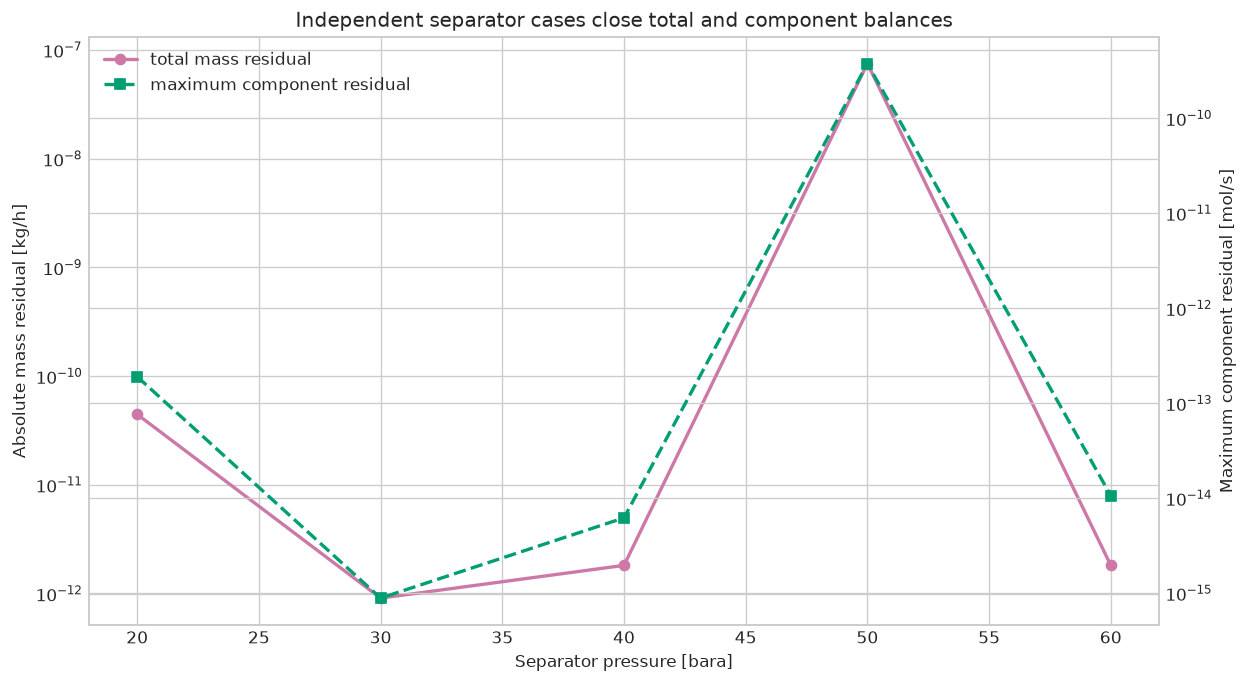

In [21]:
absolute_mass_residual = (
    separator_sensitivity["mass residual [kg/h]"].abs()
    + 1.0e-16
)
absolute_component_residual = (
    separator_sensitivity[
        "maximum component residual [mol/s]"
    ].abs()
    + 1.0e-18
)

figure, mass_axis = plt.subplots(figsize=(10.5, 5.8))
component_axis = mass_axis.twinx()
mass_axis.semilogy(
    separator_sensitivity["pressure [bara]"],
    absolute_mass_residual,
    marker="o",
    linewidth=2,
    label="total mass residual",
    color="#CC79A7",
)
component_axis.semilogy(
    separator_sensitivity["pressure [bara]"],
    absolute_component_residual,
    marker="s",
    linestyle="--",
    linewidth=2,
    label="maximum component residual",
    color="#009E73",
)
mass_axis.set_xlabel("Separator pressure [bara]")
mass_axis.set_ylabel("Absolute mass residual [kg/h]")
component_axis.set_ylabel(
    "Maximum component residual [mol/s]"
)
mass_axis.set_title(
    "Independent separator cases close total and component balances"
)
mass_lines, mass_labels = mass_axis.get_legend_handles_labels()
component_lines, component_labels = (
    component_axis.get_legend_handles_labels()
)
mass_axis.legend(
    mass_lines + component_lines,
    mass_labels + component_labels,
    loc="upper left",
)
figure.tight_layout()
plt.show()

## Acceptance checks

The final checks cover numerical convergence, phase classification, composition and flow
closure, agreement with NeqSim, operating trends, and PH/PS specification residuals. The
notebook fails immediately if a regression violates any acceptance criterion.

In [22]:
synthetic_residual = rachford_rice_value(
    synthetic_beta,
    synthetic_feed,
    synthetic_k_values,
)
single_liquid_beta, single_liquid_state, _ = solve_rachford_rice(
    feed_fractions=np.array([0.5, 0.5]),
    equilibrium_ratios=np.array([0.8, 0.4]),
)
single_vapour_beta, single_vapour_state, _ = solve_rachford_rice(
    feed_fractions=np.array([0.5, 0.5]),
    equilibrium_ratios=np.array([2.0, 1.2]),
)

assert abs(synthetic_residual) < 1e-12
assert math.isclose(float(synthetic_x.sum()), 1.0, abs_tol=1e-12)
assert math.isclose(float(synthetic_y.sum()), 1.0, abs_tol=1e-12)
assert np.max(np.abs(synthetic_reconstructed_feed - synthetic_feed)) < 1e-12
assert single_liquid_state == "liquid only"
assert single_liquid_beta == 0.0
assert single_vapour_state == "vapour only"
assert single_vapour_beta == 1.0
assert base_fluid.getNumberOfPhases() == 2
assert abs(beta_difference) < 1e-10
assert maximum_liquid_composition_difference < 1e-10
assert maximum_vapour_composition_difference < 1e-10
assert initial_guess_study["vapour fraction [-]"].std() < 1e-10
assert pressure_study["NeqSim vapour fraction [-]"].is_monotonic_decreasing
assert float(pressure_study["difference [-]"].abs().max()) < 1e-10
assert maximum_flow_residual < 1e-8
assert abs(enthalpy_residual_j) < 1e-3
assert abs(entropy_residual_j_per_k) < 1e-3
assert float(isentropic_fluid.getTemperature("K")) < float(
    throttle_fluid.getTemperature("K")
)

print("All 19 flash-calculation engineering checks passed.")

All 19 flash-calculation engineering checks passed.


In [23]:
base_recovery_sum = (
    base_component_table["gas recovery [-]"]
    + base_component_table["liquid recovery [-]"]
)
maximum_mass_residual = float(
    separator_sensitivity["mass residual [kg/h]"].abs().max()
)
maximum_component_residual = float(
    separator_sensitivity[
        "maximum component residual [mol/s]"
    ].abs().max()
)

assert np.allclose(base_recovery_sum, 1.0, atol=1.0e-10)
assert (
    separator_sensitivity["liquid flow [kg/h]"]
    .is_monotonic_increasing
)
assert (
    separator_sensitivity["gas flow [kg/h]"]
    .is_monotonic_decreasing
)
assert maximum_mass_residual < 1.0e-6
assert maximum_component_residual < 1.0e-8
assert math.isclose(
    base_separator_case["feed_mass_flow_kg_per_h"],
    base_separator_case["gas_mass_flow_kg_per_h"]
    + base_separator_case["liquid_mass_flow_kg_per_h"],
    abs_tol=1.0e-6,
)

print("All eight stream–separator application checks passed.")
print(
    "Maximum scenario mass residual: "
    f"{maximum_mass_residual:.3e} kg/h"
)
print(
    "Maximum scenario component residual: "
    f"{maximum_component_residual:.3e} mol/s"
)

All eight stream–separator application checks passed.
Maximum scenario mass residual: 7.508e-08 kg/h
Maximum scenario component residual: 3.763e-10 mol/s


## Interpretation, applicability, and limitations

The safeguarded solver reproduces the NeqSim phase split when supplied with converged
equilibrium ratios. This confirms the material-balance layer, while NeqSim supplies the harder
thermodynamic task of updating fugacity coefficients and $K_i$ values. Wilson estimates are
useful starting points but are not substitutes for an equation-of-state flash.

Rachford–Rice in this form assumes two equilibrium fluid phases and positive $K_i$ values. It
does not by itself handle three fluid phases, solids, reactions, electrolytes, metastability,
or transport rates. Near critical points, $K_i$ values approach one and both classification
and numerical conditioning require care. Real designs need characterized fluids, traceable
laboratory data, and uncertainty analysis.

### Exercises

1. Replace SRK with PR and compare converged $K_i$ values and vapour fraction.
2. Extend the pressure range until a single-phase state is reached and document the boundary.
3. Add a temperature study and draw a two-dimensional liquid-dropout map.
4. Use the PH result as the inlet to a NeqSim separator and calculate gas and liquid duties.

### NeqSim references

- [Thermodynamics recipes: TP, PH, and PS flashes](https://equinor.github.io/neqsim/cookbook/thermodynamics-recipes.html)
- [Thermodynamic operations package](https://equinor.github.io/neqsim/thermodynamicoperations/README.html)
- [Thermodynamic model selection](https://equinor.github.io/neqsim/thermo/thermodynamic_models.html)

## Application summary and reuse

The notebook now connects the Rachford–Rice material-balance layer to NeqSim's real process
functionality. A reusable case creates a fresh SRK fluid, assigns a flow with `Stream`,
performs the equilibrium split with `Separator`, executes the objects through
`ProcessSystem`, retrieves both products, and validates total and component conservation.

To reuse the workflow, replace `COMPONENTS`, temperature, pressure, and feed rate with
traceable project data. Reassess the property model, characterization, water and polar
components, phase stability, and uncertainty before design use.

### Troubleshooting

- If no liquid appears, verify temperature, pressure, composition, and multiphase checking.
- If a component lookup fails, use the exact NeqSim component name added to the fluid.
- If a sweep gives order-dependent results, create fresh fluid and equipment objects.
- If residuals are large, check flow units and use product-stream overall compositions.
- Near critical conditions, inspect phase stability and avoid interpreting a poorly
  conditioned $K_i pprox 1$ calculation as a robust design point.

The original limitations and exercises below remain applicable. A useful next extension is
to add a cooler and valve before the separator, then audit both material and energy
balances over the complete process boundary.